In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

MINIST 손글씨 데이터 불러오기

In [2]:
from keras.datasets import mnist
from keras.utils import to_categorical

2025-12-04 10:11:03.462120: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-04 10:11:04.129297: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-04 10:11:06.951946: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [4]:
len(X_train)

60000

In [5]:
X_train[0].shape

(28, 28)

In [6]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

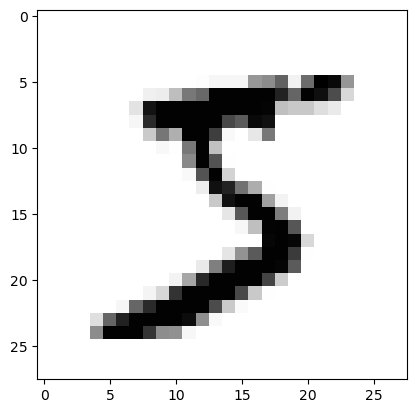

In [7]:
plt.imshow(X_train[0], cmap="Grays")
plt.show()

In [8]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [9]:
pd.DataFrame(X_train[2])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,67,232,39,0,0,0,0,0
6,0,0,0,0,62,81,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120,180,39,0,0,0,0,0
7,0,0,0,0,126,163,0,0,0,0,0,0,0,0,0,0,0,0,0,2,153,210,40,0,0,0,0,0
8,0,0,0,0,220,163,0,0,0,0,0,0,0,0,0,0,0,0,0,27,254,162,0,0,0,0,0,0
9,0,0,0,0,222,163,0,0,0,0,0,0,0,0,0,0,0,0,0,183,254,125,0,0,0,0,0,0


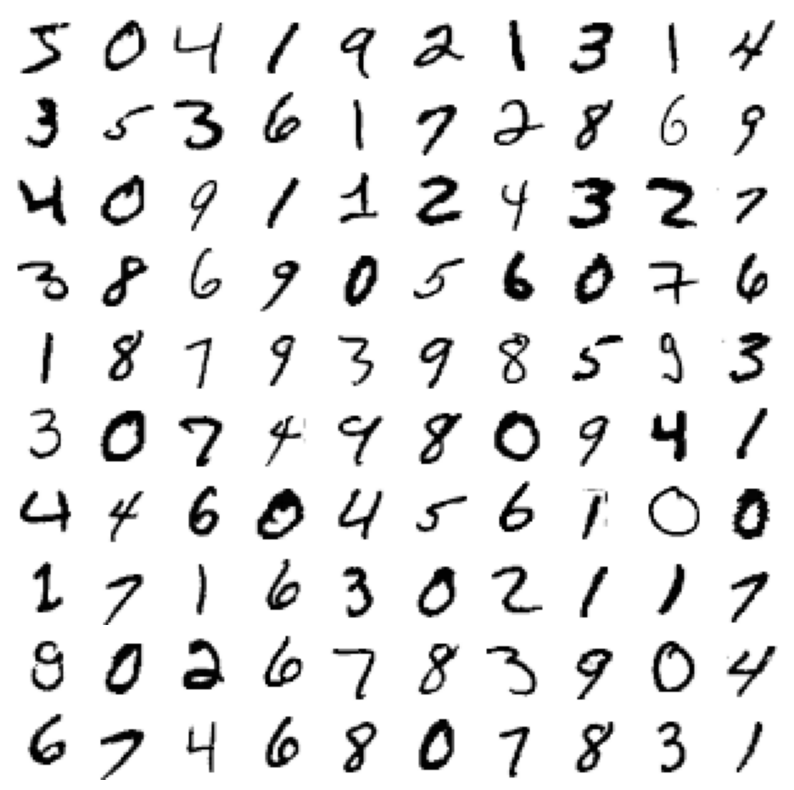

In [10]:
fig, axes = plt.subplots(10, 10, figsize=(10,10))
axes = axes.ravel()

for i in range(100):
    axes[i].imshow(X_train[i], cmap="Grays")
    axes[i].axis('off')
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

# 이미지 데이터 훈련을 위한 전처리
* 정규화 = X / 255 => 0~ 1 범위로 변환, -1~1 범위로 변환
* y 종속변수 = one-hot-encoding, to_categorical()

In [11]:
X_train.shape

(60000, 28, 28)

In [12]:
X_train.shape[1]*X_train.shape[1]

784

In [13]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1]*X_train.shape[2])
X_train.shape

(60000, 784)

In [14]:
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1]*X_test.shape[2])
print(X_test.shape)

(10000, 784)


In [15]:
X_train[:2, :]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2, 784), dtype=uint8)

# 데이터 정규화 / 255

In [16]:
X_train = X_train / 255
X_test = X_test / 255

# 종속변수 y => one-hot-encoding, to_categorical

In [17]:
y_train.shape

(60000,)

In [18]:
# y에 클래스 수 계산
len(np.unique(y_train))

10

In [19]:
# 카테고리 수를 입력해서 one-hot-encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [21]:
y_train.shape

(60000, 10)

In [22]:
y_train[:2, :]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

# DNN 훈련 및 예측
* 이미지 분석시 은닉층 노드: 작은 것 -> 큰 것 -> 작은 것

In [25]:
from keras.models import Sequential
from keras.layers import Input,Dense
from keras.callbacks import EarlyStopping,ModelCheckpoint

In [26]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1], )))
model.add(Dense(512,activation='relu'))
model.add(Dense(1024,activation='relu'))
model.add(Dense(512,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.summary()

I0000 00:00:1764811395.534242     431 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,457,162 (5.56 MB)

 Trainable params: 1,457,162 (5.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


2025-12-04 10:25:37.824691: I external/local_xla/xla/service/service.cc:163] XLA service 0x765bd800bf60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-04 10:25:37.824756: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-12-04 10:25:37.886541: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-04 10:25:38.109341: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600


12/45 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5598 - loss: 1.5093

I0000 00:00:1764811540.387192     499 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.8695 - loss: 0.4662 - val_accuracy: 0.9452 - val_loss: 0.1865
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9591 - loss: 0.1405 - val_accuracy: 0.9618 - val_loss: 0.1258
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9737 - loss: 0.0855 - val_accuracy: 0.9689 - val_loss: 0.1051
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9838 - loss: 0.0553 - val_accuracy: 0.9692 - val_loss: 0.1024
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9880 - loss: 0.0394 - val_accuracy: 0.9753 - val_loss: 0.0903
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9931 - loss: 0.0244 - val_accuracy: 0.9719 - val_loss: 0.1075
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9945 - loss: 0.0191 - val_accuracy: 0.9735 - val_loss: 0.0990
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9976 - loss: 0.0104 - val_accuracy: 0.9782 - val_l

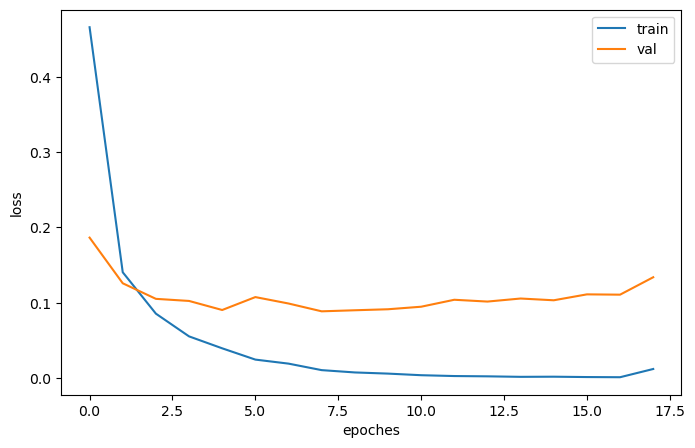

In [28]:
model.compile(loss="categorical_crossentropy",optimizer='adam',metrics=['accuracy'])
model_path = "./model/MNIST_MLP.keras"
chechpoint = ModelCheckpoint(filepath=model_path,save_best_only=True)
early_stop = EarlyStopping(patience=10,restore_best_weights=True)
history = model.fit(X_train,y_train,validation_split=0.25,epochs=100,batch_size=1000,
                   callbacks=[chechpoint,early_stop])
print("test 정확도",model.evaluate(X_test,y_test))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epoches")
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show() 

# CNN 합성곱 신경망으로 이미지 분석하기
* DNN은 이미지 데이터를 1차원으로 펼쳐서 분석
* CNN은 2차원 상태 그대로 분석

In [29]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# CNN을 위한 데이터 전처리 3차원 => 4차원
* (행(전체 데이터 개수), 이미지사이즈(행, 열), 색레이어수(흑백=1, 컬러=3))

In [30]:
X_train.shape

(60000, 28, 28)

In [31]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1).astype('float32') / 255

In [32]:
X_train.shape

(60000, 28, 28, 1)

In [33]:
X_test.shape

(10000, 28, 28, 1)

# y 종속변수 => one-hot-encoding, to_categorical(y, class수)

In [34]:
n_class = len(np.unique(y_train))

In [35]:
y_train = to_categorical(y_train, n_class)
y_test = to_categorical(y_test, n_class)

# CNN 합성 네트워크를 위한 layers
* Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [36]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [38]:
model2 = Sequential()
model2.add(Input(shape=(28, 28, 1)))
model2.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model2.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Dropout(0.25))
model2.add(Flatten())
model2.add(Dense(128, activation='relu'))
model2.add(Dense(64, activation='relu'))
model2.add(Dropout(0.25))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(10, activation='softmax'))
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,209,258 (4.61 MB)

 Trainable params: 1,209,258 (4.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


2025-12-04 10:37:50.344861: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1000,32,26,26]{3,2,1,0}, u8[0]{0}) custom-call(f32[1000,1,28,28]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-12-04 10:37:50.627823: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1000,64,24,24]{3,2,1,0}, u8[0]{0}) custom-call(f32[1000,32,26,26]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.5425 - loss: 1.3893

2025-12-04 10:38:05.045129: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1000,32,26,26]{3,2,1,0}, u8[0]{0}) custom-call(f32[1000,1,28,28]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-12-04 10:38:05.231755: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1000,64,24,24]{3,2,1,0}, u8[0]{0}) custom-call(f32[1000,32,26,26]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActiv

45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 192ms/step - accuracy: 0.7267 - loss: 0.8549 - val_accuracy: 0.9305 - val_loss: 0.2314
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - accuracy: 0.9332 - loss: 0.2256 - val_accuracy: 0.9675 - val_loss: 0.1117
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 212ms/step - accuracy: 0.9653 - loss: 0.1221 - val_accuracy: 0.9779 - val_loss: 0.0752
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 245ms/step - accuracy: 0.9752 - loss: 0.0841 - val_accuracy: 0.9795 - val_loss: 0.0659
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 251ms/step - accuracy: 0.9806 - loss: 0.0655 - val_accuracy: 0.9825 - val_loss: 0.0574
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 365ms/step - accuracy: 0.9836 - loss: 0.0542 - val_accuracy: 0.9846 - val_loss: 0.0544
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.9869 - loss: 0.0454 - val_accuracy: 0.9860 - val_loss: 0.0487
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 0.9883 - loss: 0.0382 - val_accuracy: 0.

2025-12-04 10:41:56.816107: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,26,26]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,1,28,28]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-12-04 10:41:57.339863: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,24,24]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,26,26]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFor

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9873 - loss: 0.0410

2025-12-04 10:42:13.916910: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,64,24,24]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,26,26]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}


313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.9899 - loss: 0.0337
test 정확도 [0.033726658672094345, 0.9898999929428101]


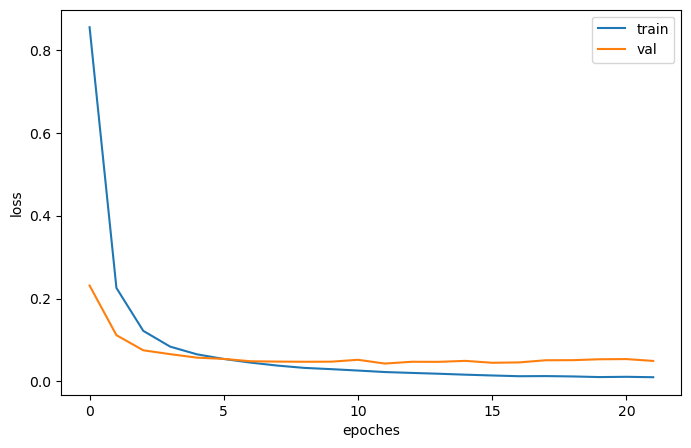

In [39]:
model2.compile(loss="categorical_crossentropy",optimizer='adam',metrics=['accuracy'])
model_path = "./model/MNIST_CNN.keras"
chechpoint = ModelCheckpoint(filepath=model_path,save_best_only=True)
early_stop = EarlyStopping(patience=10,restore_best_weights=True)
history2 = model2.fit(X_train,y_train,validation_split=0.25,epochs=100,batch_size=1000,
                   callbacks=[chechpoint,early_stop])
print("test 정확도",model2.evaluate(X_test,y_test))
plt.figure(figsize=(8,5))
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.xlabel("epoches")
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()